In [1]:
# Native libraries
import os
import math
# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Preprocessing
from sklearn.preprocessing import MinMaxScaler
# Algorithms
#from minisom import MiniSom
from tslearn.barycenters import dtw_barycenter_averaging
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans
import cartopy.crs as ccrs
import cartopy
import susi
from sklearn.model_selection import GridSearchCV
import xarray as xr
import matplotlib._color_data as mcd

from sklearn.decomposition import PCA

/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/clustering/kmeans.py:17: UserWarning: Scikit-learn <0.24 will be deprecated in a future release of tslearn
  "Scikit-learn <0.24 will be deprecated in a "


In [2]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)

metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/all_sites_all_seasons.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# define alpha and numeric season order
seasons_a = ['fall','winter','spring','summer']
seasons_n = [3,6,9,12]

colors = ['r','b',"#000000", "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
"#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF", "#997D87",
"#5A0007", "#809693", "#FEFFE6", "#1B4400", "#4FC601", "#3B5DFF", "#4A3B53", "#FF2F80",
"#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9", "#B903AA", "#D16100",
"#DDEFFF", "#000035", "#7B4F4B", "#A1C299", "#300018", "#0AA6D8", "#013349", "#00846F",
"#372101", "#FFB500", "#C2FFED", "#A079BF", "#CC0744", "#C0B9B2", "#C2FF99", "#001E09",
"#00489C", "#6F0062", "#0CBD66", "#EEC3FF", "#456D75", "#B77B68", "#7A87A1", "#788D66",
"#885578", "#FAD09F", "#FF8A9A", "#D157A0", "#BEC459", "#456648", "#0086ED", "#886F4C",
"#34362D", "#B4A8BD", "#00A6AA", "#452C2C", "#636375", "#A3C8C9", "#FF913F", "#938A81",
"#575329", "#00FECF", "#B05B6F", "#8CD0FF", "#3B9700", "#04F757", "#C8A1A1", "#1E6E00",
"#7900D7", "#A77500", "#6367A9", "#A05837", "#6B002C", "#772600", "#D790FF", "#9B9700",
"#549E79", "#FFF69F", "#201625", "#72418F", "#BC23FF", "#99ADC0", "#3A2465", "#922329",
"#5B4534", "#FDE8DC", "#404E55", "#0089A3", "#CB7E98", "#A4E804", "#324E72", "#6A3A4C"]

colors.pop(34)
colors.pop(35)
colors.pop(20)
colors[15], colors[40] = colors[40], colors[15]


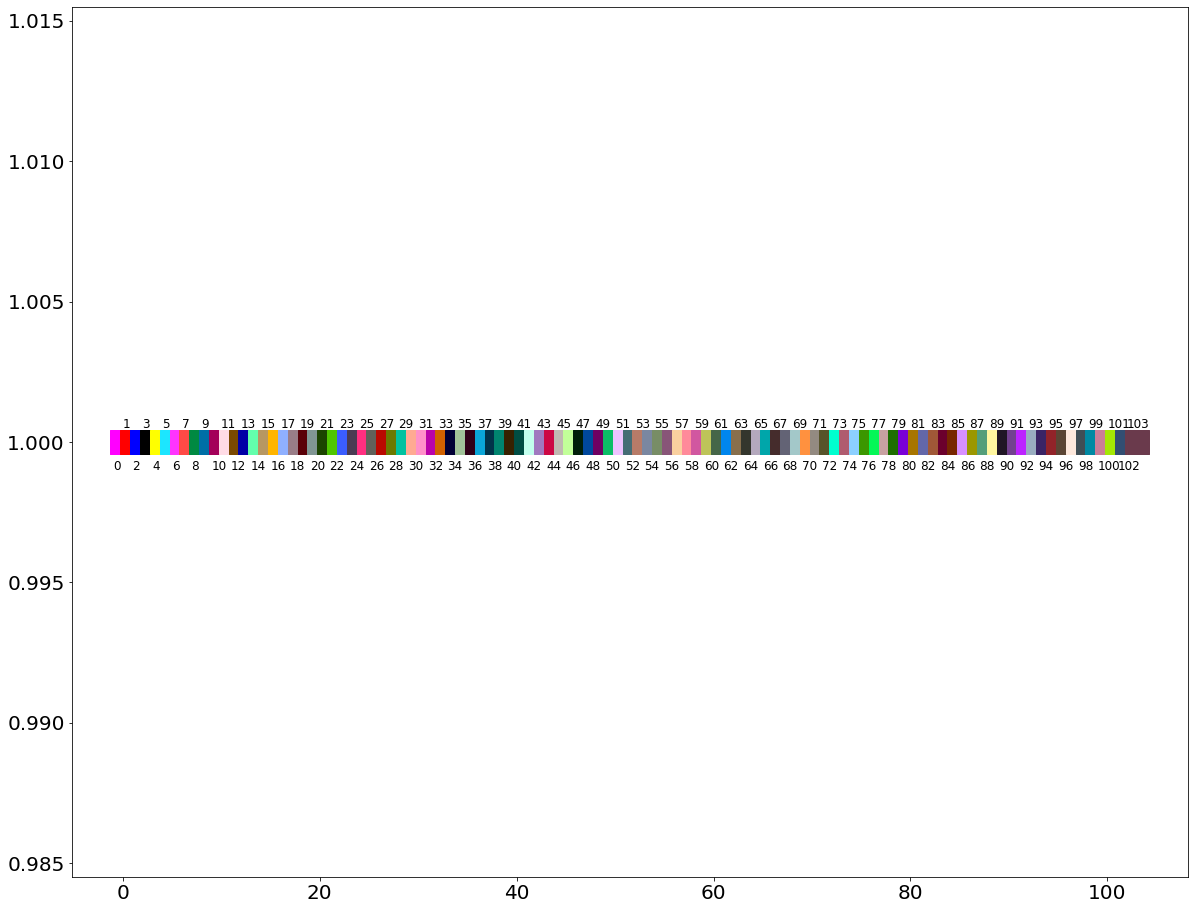

In [131]:
fig,ax = plt.subplots(figsize=(20,16))
plt.scatter([i for i in range(len(colors))],[1 for i in range(len(colors))],c=colors,marker='s',s=600)

for i in range(len(colors)):
    if i%2:
        plt.text(i-1,1.0005,str(i),fontsize=12)
    else:
        plt.text(i-1,0.999,str(i),fontsize=12)


In [3]:
cell_list = [
       '-35.5508 174.0', '-37.0477 174.75', '-37.0477 175.5',
       '-37.7961 175.5', '-37.7961 177.75', '-38.5446 174.75',
       '-38.5446 175.5', '-38.5446 176.25', '-38.5446 177.0',
       '-38.5446 177.75', '-39.2930 174.0', '-39.2930 174.75',
       '-39.2930 175.5', '-39.2930 176.25', '-40.0414 176.25',
       '-40.7899 172.5', '-40.7899 175.5', '-40.7899 176.25',
       '-41.5383 172.5', '-41.5383 173.25', '-41.5383 174.0',
       '-42.2867 171.75', '-42.2867 172.5', '-42.2867 173.25',
       '-43.0352 171.0', '-43.0352 172.5', '-43.7836 169.5',
       '-43.7836 170.25', '-43.7836 171.0', '-43.7836 171.75',
       '-44.5321 168.75', '-44.5321 169.5', '-44.5321 171.0',
       '-45.2805 168.0', '-45.2805 168.75', '-45.2805 170.25',
       '-46.0289 167.25', '-46.0289 168.0', '-46.0289 168.75',
       '-46.0289 169.5', '-46.0289 170.25']

In [4]:
file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ens01_197901-201902.nc'
file_path = '../../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ens01/' + file_name

example_member = xr.open_dataset(file_path)
example_member = example_member['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
example_da = example_member.sel(time=example_member.time.dt.month.isin([3]))

example_stacked = example_da.stack(grid_cell=('lat','lon'))

mask_array = np.zeros(example_stacked.shape)

for i,cell in enumerate(example_stacked.indexes['grid_cell']):
    
    coords = str(cell[0])[:8] + " " + str(cell[1])
        
    if coords in cell_list:
        mask_val = 1
    else:
        mask_val = 0
    for k in range(len(example_da.time.values)):
        mask_array[k][i] = mask_val
        
mask_array.shape

(40, 598)

In [3]:
df = flow_df[flow_df.index.month.isin([9])]
#df = flow_df.resample('A').mean()


In [4]:
df = df.fillna(df.mean())
normalized_df=((df-df.mean())/df.std()).T
#normalized_df=((df-df.min())/(df.max()-df.min())).T


In [160]:
len(normalized_df)

53

SELF ORGANIZING MAPS

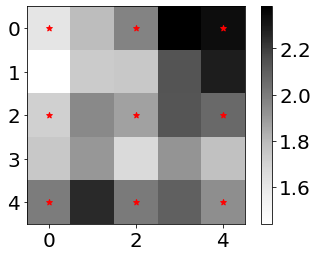

In [167]:
som_x = som_y = 3#math.ceil(math.sqrt(math.sqrt(len(normalized_df))))

X = normalized_df.values

som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=50000,learning_rate_start=0.5,learning_rate_end=0.005,)
som.fit(X)

fig,ax = plt.subplots()

umat = som.get_u_matrix()
p = plt.imshow(np.squeeze(umat),cmap='Greys')

plt.scatter([[2*i]*som_x for i in range(som_x)],[2*i for i in range(som_x)]*som_x,marker='*',c='r')

fig.colorbar(p)

In [183]:
def plot_som_series_averaged_center(som_x, som_y):
    fig, axs = plt.subplots(som_x,som_y,sharex=True,sharey=True,figsize=(18,18))
    
    plt.rc('font', size=20)          # controls default text sizes
    plt.rc('axes', titlesize=20)     # fontsize of the axes title
    plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=20)    # fontsize of the tick labels
    plt.rc('legend', fontsize=20)    # legend fontsize
    plt.rc('figure', titlesize=20)  # fontsize of the figure title
    
    for x in range(som_x):
        for y in range(som_y):
            cluster = (x,y)
            cluster_number = x*som_y+y+1
            
            series_indices = som.get_datapoints_from_node(cluster)
            
            ts_list = []
            for i in series_indices:
                ts = X[i]
                ts_list.append(ts)
                axs[cluster].plot(ts,c="gray",alpha=0.5) 
            
            if ts_list == []:
                continue
            axs[cluster].plot(dtw_barycenter_averaging(ts_list),c=colors[cluster_number-1],linewidth=3,label=str(x) + " " + str(y))
            
            #cluster_number = x*som_y+y+1
            #axs[cluster].set_title(str(x) + " " + str(y))
            axs[cluster].legend(loc='upper left')


    plt.tight_layout()
    plt.show()

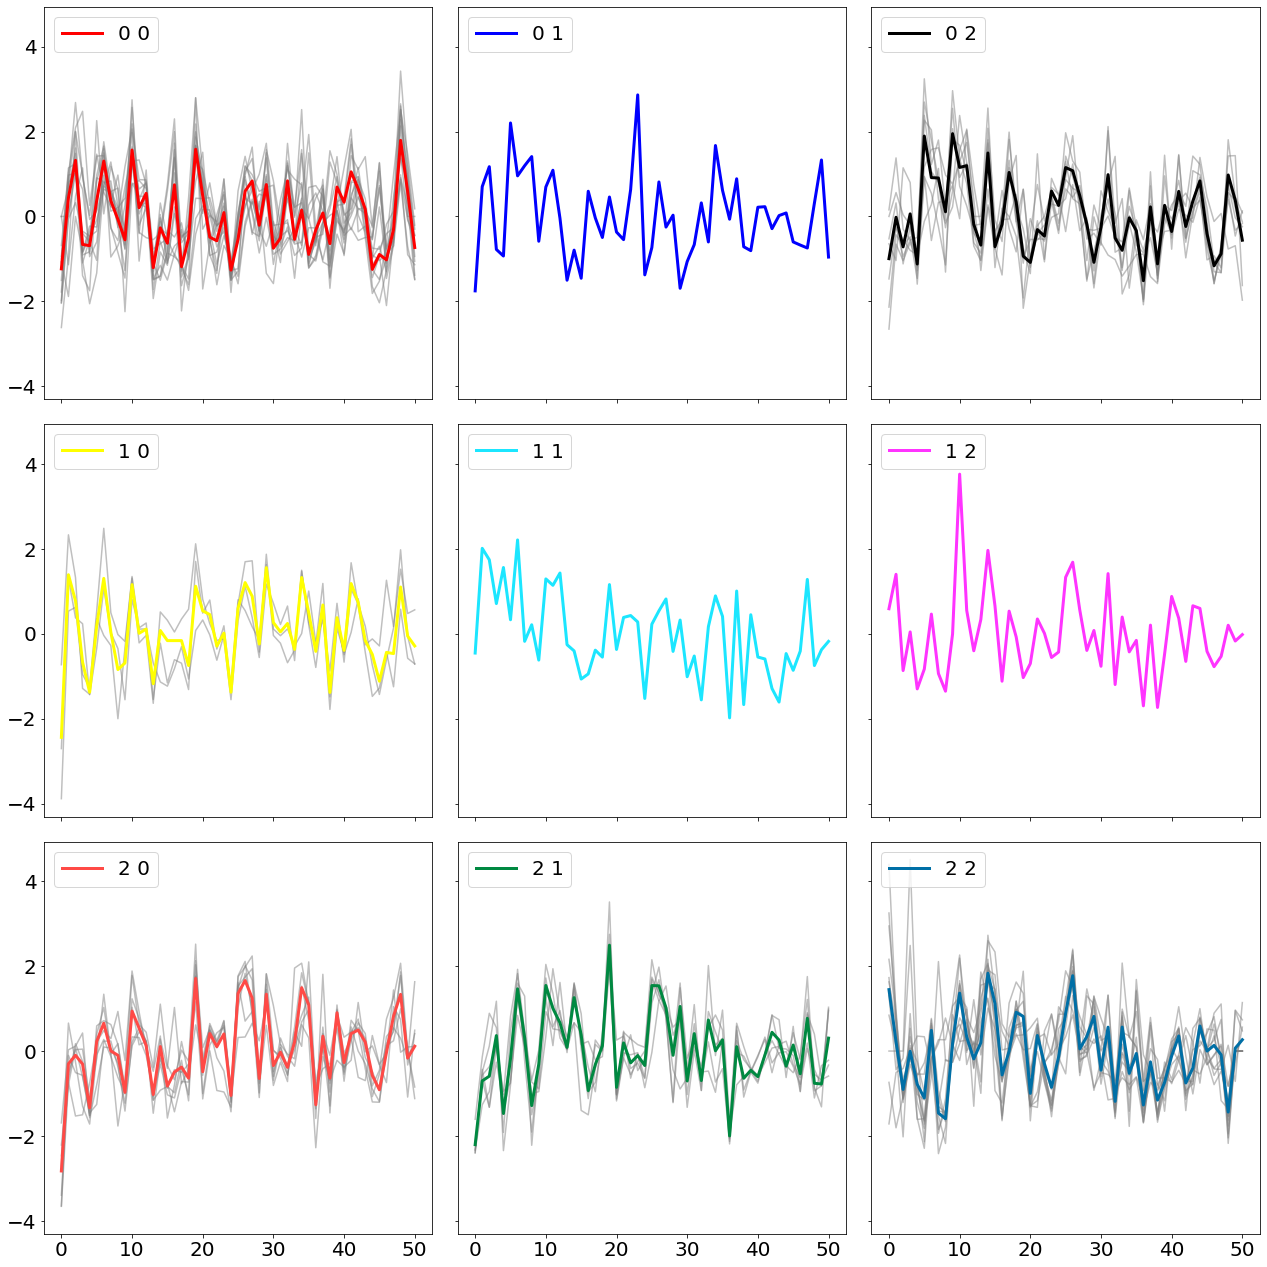

In [184]:
plot_som_series_averaged_center(som_x,som_y)

<BarContainer object of 9 artists>

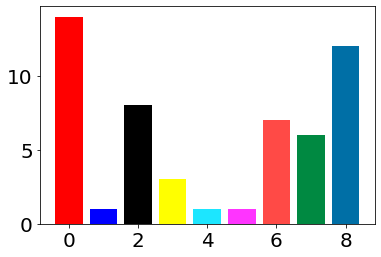

In [170]:
count_dict = {}
for x in range(som_x):
    for y in range(som_y):
        cluster = (x,y)
        cluster_number = x*som_y+y+1


        series_indices = som.get_datapoints_from_node(cluster)
        
        count_dict[cluster_number] = len(series_indices)

clusters = [i for i in range(len(count_dict.values()))]
plt.bar(clusters,count_dict.values(),color=[colors[val-1] for val in count_dict.keys()])



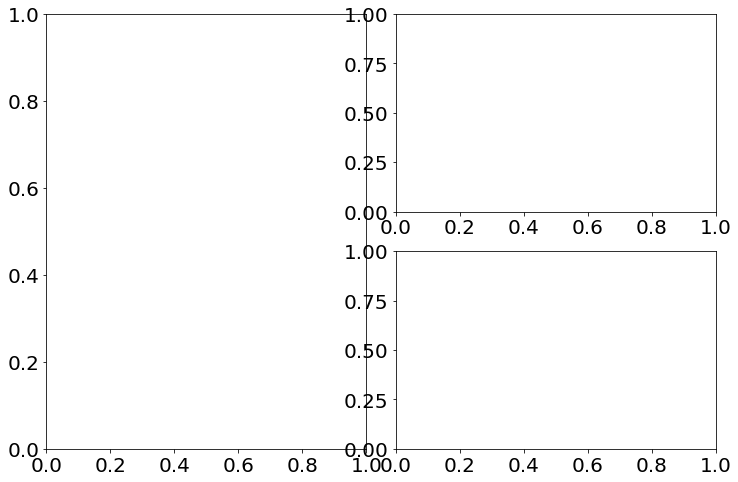

In [200]:
fig = plt.figure()
fig.set_figheight(8)
fig.set_figwidth(12)
  
ax1 = plt.subplot2grid(shape=(2, 4), loc=(0, 0), colspan=2,rowspan=2)
ax2 = plt.subplot2grid(shape=(2, 4), loc=(0, 2), colspan=2)
ax3 = plt.subplot2grid(shape=(2, 4), loc=(1, 2), colspan=2)



In [171]:
sites = normalized_df.index.values

lons = []
lats = []
clusters = []

for x in range(som_x):
    for y in range(som_y):
        cluster = (x,y)
        cluster_number = x*som_y+y+1
        
        series_indices = som.get_datapoints_from_node(cluster)
        
        for i in series_indices:
            site = int(sites[i])
            
            lons.append(metadata_df.loc[site]['centroid_lon'])
            lats.append(metadata_df.loc[site]['centroid_lat'])
            clusters.append(cluster_number)
        

(164, 180)

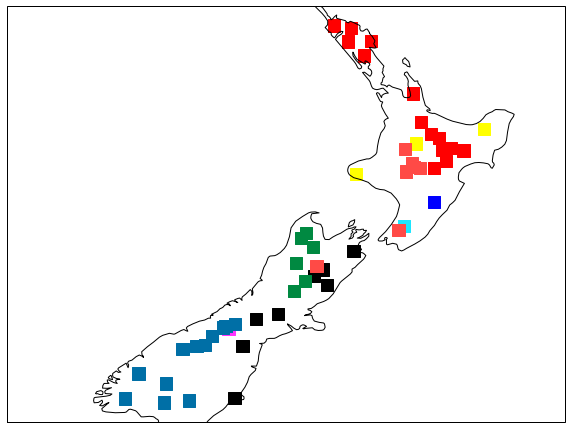

In [172]:

plt.figure(figsize=(10,10))
ax=plt.axes(projection=ccrs.PlateCarree())

ax.scatter(lons,lats,marker='s',s=150,c=[colors[val-1] for val in clusters])#c=[colors[val-1] for val in clusters],marker='s',s=150)

ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.set_xlim([164,180])


In [58]:
len(list(mcd.XKCD_COLORS.keys()))

949

In [126]:
#math.ceil(math.sqrt(math.sqrt(len(normalized_df))))
df = flow_df[flow_df.index.month.isin([6])]

df = df.fillna(df.mean())
normalized_df=((df-df.mean())/df.std()).T

mesh_sizes = [2]*16#3,4]
sites = normalized_df.index.values

#print(normalized_df)
X = normalized_df.values
print(X.shape)
print(df)
'''
fig, axs = plt.subplots(4,4,figsize=(25,20),squeeze=True,subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()

for i,size in enumerate(mesh_sizes):
    
    #print(i)
    
    som_x = som_y = size
    
    som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=50000,learning_rate_start=0.1,learning_rate_end=0.005,)
    som.fit(X)


    lons = []
    lats = []
    clusters = []

    for x in range(som_x):
        for y in range(som_y):
            cluster = (x,y)
            cluster_number = x*som_y+y+1

            series_indices = som.get_datapoints_from_node(cluster)

            for j in series_indices:
                site = int(sites[j])

                lons.append(metadata_df.loc[site]['centroid_lon'])
                lats.append(metadata_df.loc[site]['centroid_lat'])
                clusters.append(cluster_number)

    axs[i].scatter(lons,lats,c=[colors[val-1] for val in clusters],marker='s',s=150)

    axs[i].coastlines(resolution='50m', color='black', linewidth=1)
    axs[i].set_xlim([164,180])
    
    axs[i].set_title(str(size) + "x" + str(size))

'''

(53, 50)
                 1043427      1043428       1043461      1043466  \
date                                                               
1970-06-01  14313.342618  6651.108696  17746.369570  4772.934783   
1971-06-01  11430.880430  5831.347826  13829.880430  5280.500000   
1972-06-01  15337.619570  6764.163043  11935.445650  6254.706522   
1973-06-01   9580.326087  4701.239130  10370.065220  4132.989130   
1974-06-01  15577.663040  7318.326087  19333.021740  5797.315217   
1975-06-01  17596.619570  5581.324361  17147.438200  7232.054348   
1976-06-01  15831.760870  6522.891304  16930.250000  7257.989130   
1977-06-01  16693.771740  6860.597826  15591.597700  7906.750000   
1978-06-01  10645.195650  4601.391304  12541.826090  4322.239130   
1979-06-01  11620.902170  6337.326087  11495.554350  5979.967391   
1980-06-01  14313.342618  5679.456522  14626.130430  6404.500000   
1981-06-01  15587.010870  6412.869565  17173.771740  6757.141176   
1982-06-01   9275.369565  3842.923913  

'\nfig, axs = plt.subplots(4,4,figsize=(25,20),squeeze=True,subplot_kw={\'projection\': ccrs.PlateCarree()})\naxs = axs.flatten()\n\nfor i,size in enumerate(mesh_sizes):\n    \n    #print(i)\n    \n    som_x = som_y = size\n    \n    som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=50000,learning_rate_start=0.1,learning_rate_end=0.005,)\n    som.fit(X)\n\n\n    lons = []\n    lats = []\n    clusters = []\n\n    for x in range(som_x):\n        for y in range(som_y):\n            cluster = (x,y)\n            cluster_number = x*som_y+y+1\n\n            series_indices = som.get_datapoints_from_node(cluster)\n\n            for j in series_indices:\n                site = int(sites[j])\n\n                lons.append(metadata_df.loc[site][\'centroid_lon\'])\n                lats.append(metadata_df.loc[site][\'centroid_lat\'])\n                clusters.append(cluster_number)\n\n    axs[i].scatter(lons,lats,c=[colors[val-1] for val in clusters],marker=\'s\',s=150)\n\n    axs[i].coastlin

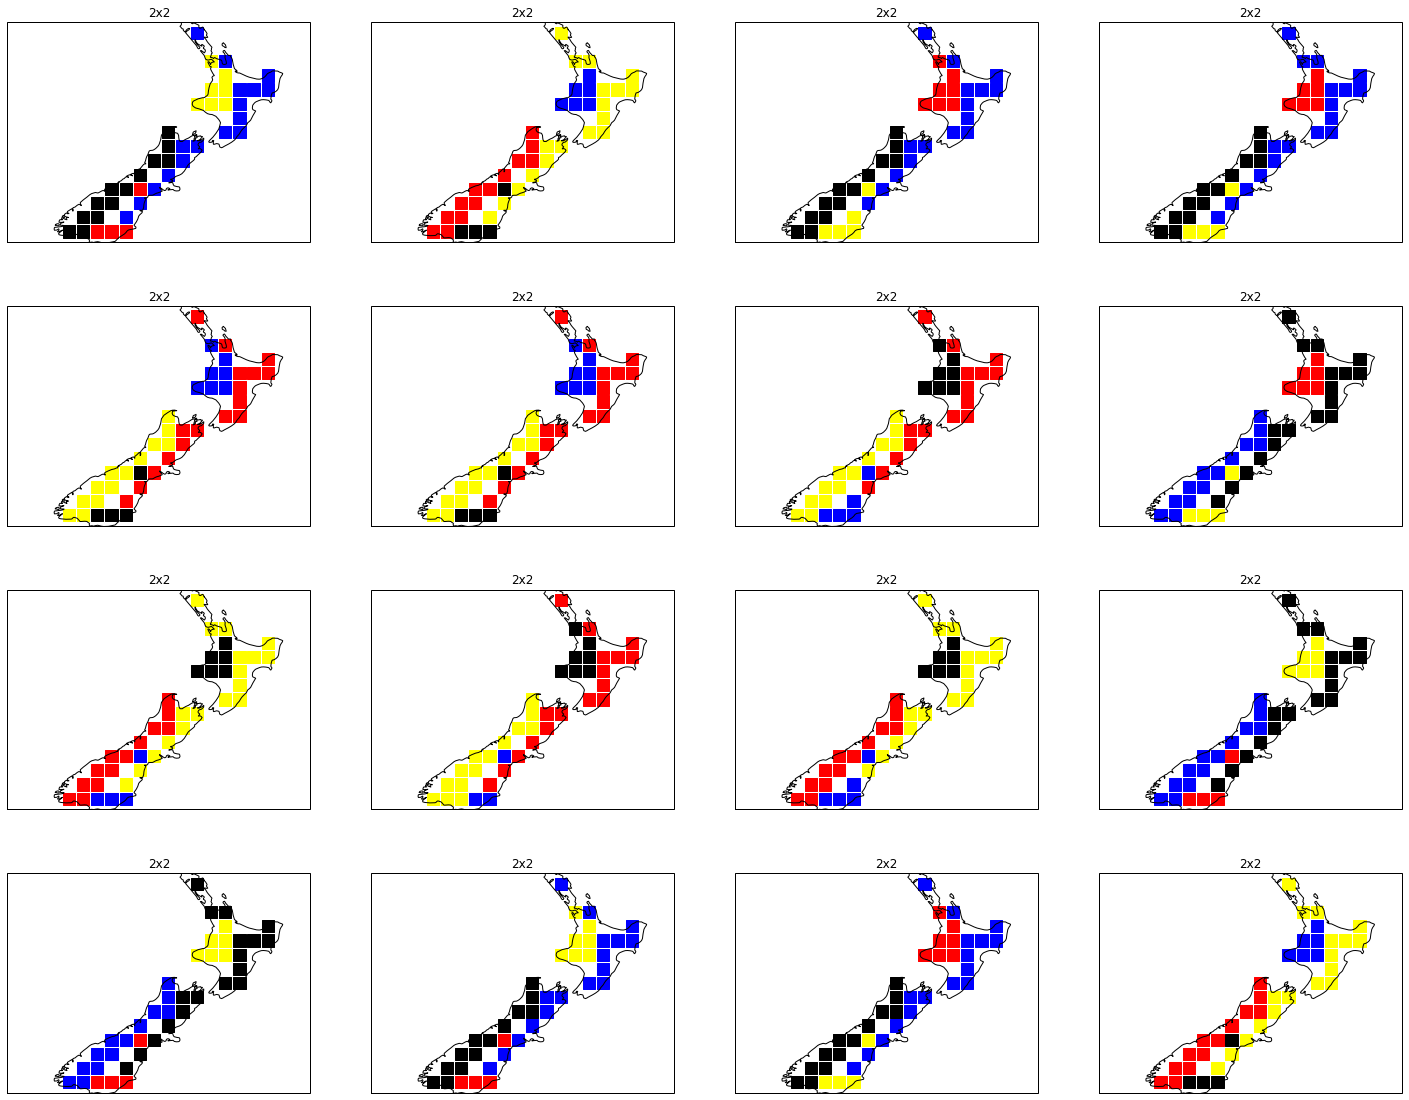

In [5]:
file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ens01_197901-201902.nc'
file_path = '../../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ens01/' + file_name

ens_mem = xr.open_dataset(file_path)

# grab time window, resample to seasonal
ens_mem = ens_mem['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
# select season
season_da = ens_mem.sel(time=ens_mem.time.dt.month.isin([6]))
# stack lat, lon
season_da = season_da.stack(grid_cell=('lat','lon'))
# add mask coordinate
season_da.coords['mask'] = (('time','grid_cell'),mask_array)
# mask runoff to only cells with observed records
season_da = season_da.where(season_da.mask == 1,drop=True)

#print(season_da)
df = pd.DataFrame(season_da.values,index=season_da.time.values, columns = season_da.grid_cell.values)
#print(df)
normalized_df=((df-df.mean())/df.std()).T

X = normalized_df.values

#print(X.shape)

mesh_sizes = [2]*16#3,4]
sites = normalized_df.index.values

#print(sites)

fig, axs = plt.subplots(4,4,figsize=(25,20),squeeze=True,subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()

for i,size in enumerate(mesh_sizes):
    
    #print(i)
    
    som_x = som_y = size
    
    som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=50000,learning_rate_start=0.5,learning_rate_end=0.005,)
    som.fit(X)


    lons = []
    lats = []
    clusters = []

    for x in range(som_x):
        for y in range(som_y):
            cluster = (x,y)
            cluster_number = x*som_y+y+1

            series_indices = som.get_datapoints_from_node(cluster)

            for j in series_indices:
                site = sites[j]

                lons.append(site[1])
                lats.append(site[0])
                clusters.append(cluster_number)

    axs[i].scatter(lons,lats,c=[colors[val-1] for val in clusters],marker='s',s=150)

    axs[i].coastlines(resolution='50m', color='black', linewidth=1)
    axs[i].set_xlim([164,180])
    
    axs[i].set_title(str(size) + "x" + str(size))



K-MEANS CLUSTERING

In [5]:
X = normalized_df.values

cluster_count = 5#math.ceil(math.sqrt(len(X))) 
# A good rule of thumb is choosing k as the square root of the number of points in the training data set in kNN

km = TimeSeriesKMeans(n_clusters=cluster_count, metric="dtw")

labels = km.fit_predict(X)

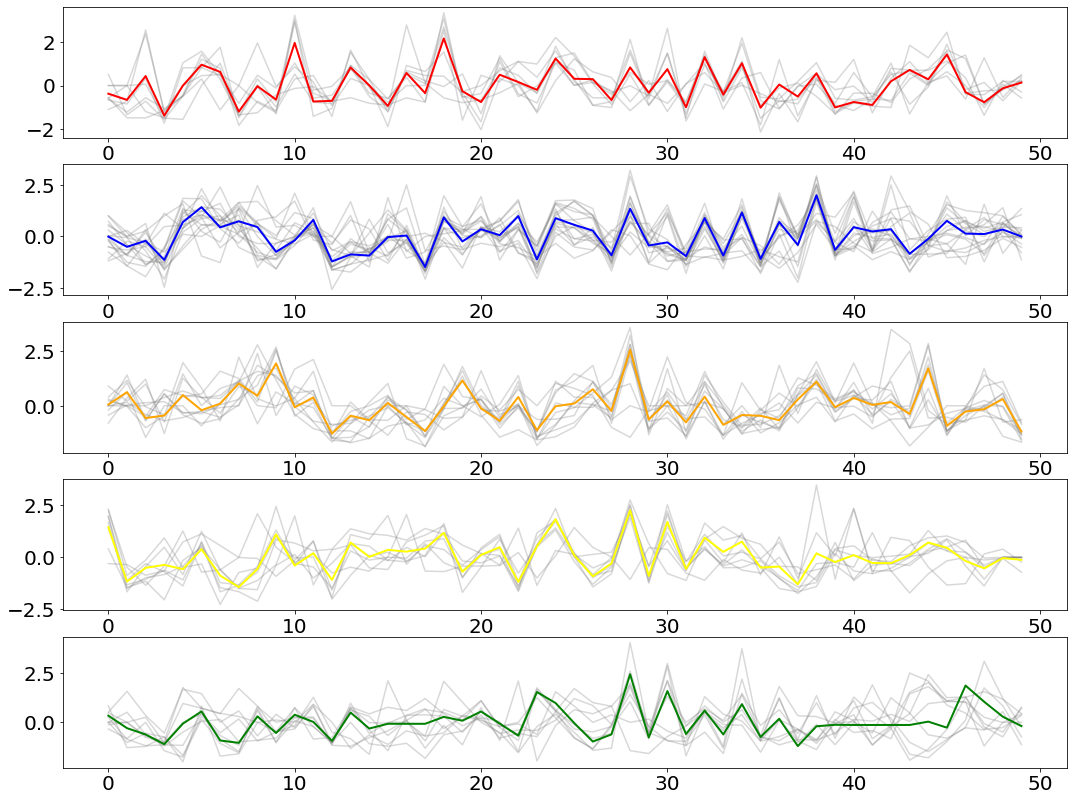

In [106]:
fig, axs = plt.subplots(cluster_count,1,figsize=(18,14),squeeze=True)

plt.rc('font', size=20)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
plt.rc('ytick', labelsize=20)    # fontsize of the tick labels
plt.rc('legend', fontsize=20)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

sites = normalized_df.index.values

lons = []
lats = []
clusters = []

ts_dict = {}

for i in range(len(labels)):

    site = int(sites[i])
    cluster = labels[i]
    
    lons.append(metadata_df.loc[site]['centroid_lon'])
    lats.append(metadata_df.loc[site]['centroid_lat'])
    clusters.append(cluster)
        
    ts = X[i]
    
    if cluster not in ts_dict:
        ts_dict[cluster] = []
        
    ts_dict[cluster].append(ts)
    
    axs[cluster].plot(ts,c="gray",alpha=0.3)

for cluster in ts_dict:
    ts_list = ts_dict[cluster]
    axs[cluster].plot(dtw_barycenter_averaging(ts_list),c=colors[cluster],linewidth=2)


In [107]:
labels
    

array([1, 2, 1, 1, 2, 4, 4, 3, 1, 2, 1, 1, 1, 4, 1, 1, 1, 2, 1, 4, 2, 2,
       2, 1, 1, 1, 4, 1, 1, 0, 3, 0, 1, 0, 2, 4, 3, 3, 4, 3, 4, 2, 0, 3,
       4, 0, 0, 3, 3, 2, 2, 0, 0])

[8, 17, 11, 8, 9]


<BarContainer object of 5 artists>

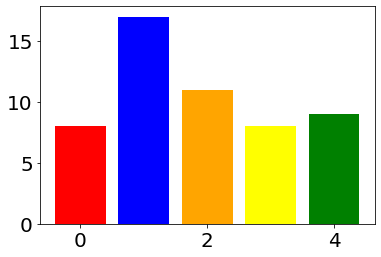

In [108]:
counts = []
for cluster in range(cluster_count):
    counts.append((labels==cluster).sum())
    
print(counts)
plt.bar([i for i in range(cluster_count)],counts,color=[colors[val] for val in range(cluster_count)])

(164, 180)

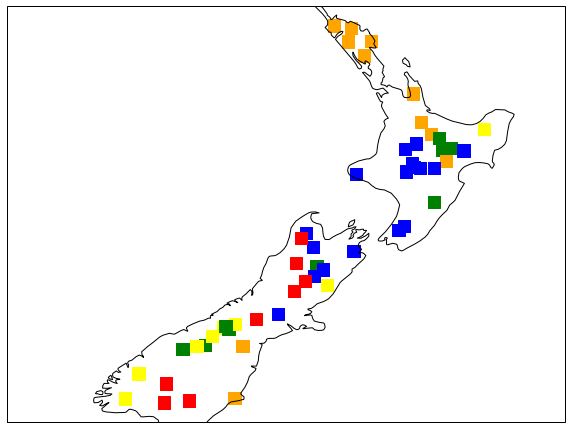

In [109]:
colors = ['red','blue','orange','yellow','green','black','grey','brown','cyan','crimson',
          'magenta','beige','salmon','deeppink','indigo','springgreen']

plt.figure(figsize=(10,10))
ax=plt.axes(projection=ccrs.PlateCarree())

ax.scatter(lons,lats,c=[colors[val] for val in clusters],marker='s',s=150)

ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.set_xlim([164,180])

2
0
1
2
3


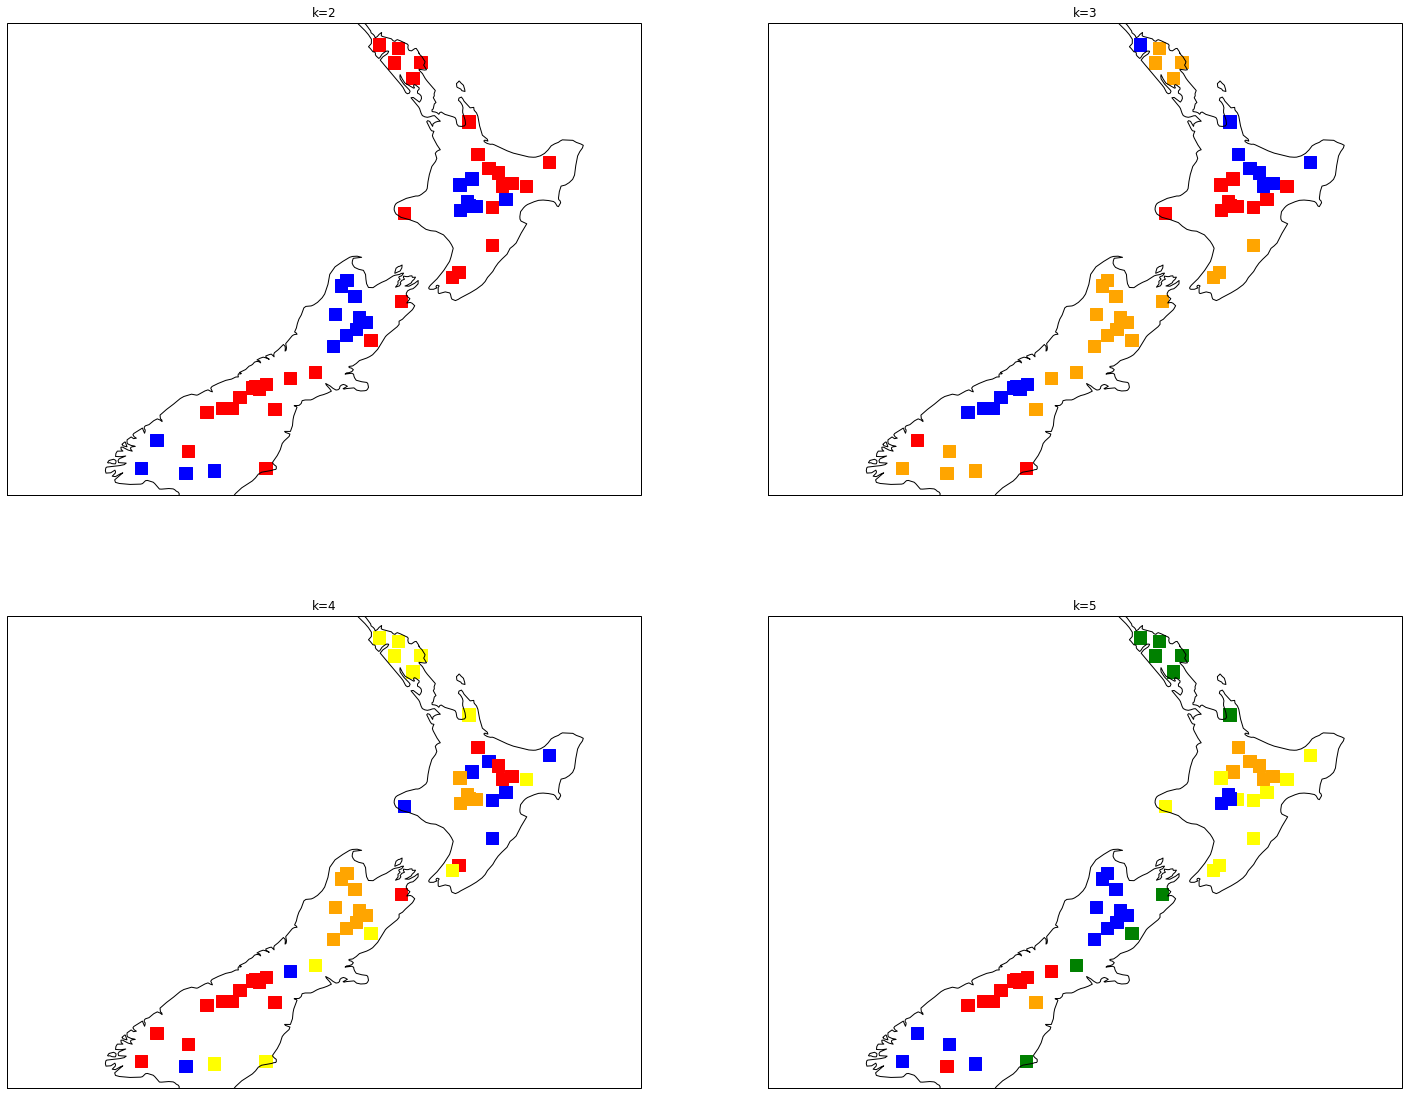

In [6]:
X = normalized_df.values
sites = normalized_df.index.values
colors = ['red','blue','orange','yellow','green','black','grey','brown','cyan','crimson',
          'magenta','beige','salmon','deeppink','indigo','springgreen']

cluster_counts = [2,3,4,5]#math.ceil(math.sqrt(len(X))) 
fig_shape = math.ceil(math.sqrt(len(cluster_counts)))

print(fig_shape)

fig, axs = plt.subplots(fig_shape,fig_shape,figsize=(25,20),squeeze=True,subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()

for i,count in enumerate(cluster_counts):
    
    print(i)
    km = TimeSeriesKMeans(n_clusters=count, metric="dtw")

    labels = km.fit_predict(X)

    lons = []
    lats = []
    clusters = []

    for j in range(len(labels)):

        site = int(sites[j])
        cluster = labels[j]

        lons.append(metadata_df.loc[site]['centroid_lon'])
        lats.append(metadata_df.loc[site]['centroid_lat'])
        clusters.append(cluster)

    axs[i].scatter(lons,lats,c=[colors[val] for val in clusters],marker='s',s=150)

    axs[i].set_title('k=' + str(count))
    axs[i].coastlines(resolution='50m', color='black', linewidth=1)
    axs[i].set_xlim([164,180])
    
    

In [121]:
print(axs)

[[<cartopy.mpl.geoaxes.GeoAxesSubplot object at 0x2aab1b716278>
